## Testing Suspect - A (timestep correlation)

In [1]:
import numpy as np
import scipp as sc
import matplotlib.pyplot as plt 
import MDAnalysis as mda
from MDAnalysis.coordinates.memory import MemoryReader
from kinisi.analyze import DiffusionAnalyzer
from tqdm import tqdm
from pathlib import Path

In [2]:
def walk(atoms, timesteps, jump_size, seed):
    possible_moves = np.zeros((6, 3))

    j = 0

    for i in range(0, 6, 2):

        possible_moves[i, j] = jump_size

        possible_moves[i + 1, j] = -jump_size

        j += 1
    choices = seed.choice(6, size=(atoms, timesteps))

    steps = possible_moves[choices]

    return np.cumsum(steps, axis=1)

In [3]:
def raw_covariance(d):

    da = d.dg['da']

    variances = da.data.variances

    n_samples = da.coords['n_samples'].values

    n = variances.size

    cov = np.zeros((n, n))

    for i in range(n):

        for j in range(i, n):

            ratio = n_samples[i] / n_samples[j]

            cov[i, j] = ratio * variances[i]

            cov[j, i] = cov[i, j]

    regime = d.diff.diff_regime
    
    return cov[regime:, regime:]

can comment out  below section after runned once

In [4]:
# data = Path.home() / "Desktop" / "Dissertation" / "kappa-kinisi" / "data"

# data.mkdir(parents=True, exist_ok=True)


# step = 1

# length = int(2 ** 7)

# atoms = int(2 ** 7)

# jump = np.sqrt(6)

# size = int(2 ** 12)



# D = np.zeros((size, 3200))

# cov = np.zeros((size, (length - 2) // step, (length - 2) // step))

# msd = np.zeros((size, (length - 2) // step, 4))



# for i in tqdm(range(size)):
#     rng = np.random.RandomState(i)

#     steps = walk(atoms, length, jump, rng)

#     dims = np.tile([200.0, 200.0, 200.0, 90.0, 90.0, 90.0], (steps.shape[1], 1))

#     u = mda.Universe.empty(steps.shape[0], trajectory=True)
#     u.add_TopologyAttr('name', [f'Atom{k}' for k in range(steps.shape[0])])
#     u.add_TopologyAttr('type', ['A'] * steps.shape[0])
#     u.trajectory = MemoryReader(np.transpose(steps, (1, 0, 2)), dimensions=dims, delta=1.0)

    
#     d = DiffusionAnalyzer.from_universe(
#         u, time_step=1.0 * sc.Unit('s'), step_skip=1,
#         distance_unit=sc.Unit('m'), specie='A',
#         dt=sc.linspace(dim='time interval', start=2 * sc.Unit('s'),
#                        stop=length * sc.Unit('s'), num=int((length - 2) / step)),
#         progress=False)
    

#     d.diffusion(2 * sc.Unit('s'), progress=False)


#     D[i, :] = d.D.values

#     cov[i, :, :] = raw_covariance(d)

#     msd[i, :, 0] = d.dt.values

#     msd[i, :, 1] = d.msd.values

#     msd[i, :, 2] = d.msd.variances

#     msd[i, :, 3] = d.da.coords['n_samples'].values

# np.savez_compressed(data / f'kinisi_rw_data_{step}.npz', D=D, cov=cov, msd=msd)

# print("saved", data / f'kinisi_rw_data_{step}.npz')

In [5]:
base = Path.home() / "Desktop" / "Dissertation" / "kappa-kinisi"

d = np.load(base / "data" / "kinisi_rw_data_1.npz")

cov = d["cov"]

msd = d["msd"]


length = 128

dimensionality = 3

D = 6 / (dimensionality * 2)

timestep = msd[0, :, 0]

no = msd[0, :, 3]

an_cov = np.zeros((no.shape[0], no.shape[0]))

for i in range(an_cov.shape[0]):

    for j in range(i, an_cov.shape[1]):

        an_cov[i, j] = 8 * dimensionality**2 * D**2 * timestep[i]**2 / (dimensionality * no[j])

        an_cov[j, i] = an_cov[i, j]

print("sample cov shape:", cov.shape)

print("analytical cov shape:", an_cov.shape)

sample cov shape: (4096, 126, 126)
analytical cov shape: (126, 126)


eig works on any matrix and returns unsorted (sometimes complex) eigenvalues; eigvalsh is for symmetric matrices and returns real, sorted ones. Our covariance matrices are symmetric and near singular, so eigvalsh is more accurate on the tiny eigenvalues that's what i use everywhere below.

In [6]:
a = np.array([[2.0, 1.0],
              [1.0, 2.0]])   # symmetric



print("eig:")
vals, vecs = np.linalg.eig(a)
print("  eigenvalues:", vals)        # returns vals and vecs, maybe unsorted



print("eigvalsh:")
vals_h = np.linalg.eigvalsh(a)      # returns only vals  with more sorted form 
print("  eigenvalues:", vals_h)

eig:
  eigenvalues: [3. 1.]
eigvalsh:
  eigenvalues: [1. 3.]


In [7]:
base = Path.home() / "Desktop" / "Dissertation" / "kappa-kinisi"

d = np.load(base / "data" / "kinisi_rw_data_1.npz")

cov = d["cov"]

max_diff = 0.0
for k in range(cov.shape[0]):
    a = np.linalg.eigvalsh(cov[k])
    b = np.linalg.eigh(cov[k])[0]
    max_diff = max(max_diff, np.max(np.abs(a - b)))

print("difference:", max_diff)

print("all are same ?", max_diff < 1e-9)

difference: 2.9103830456733704e-10
all are same ? True


compare eigenvalues = sample vs analytical 

In [8]:
ev = np.linalg.eigvalsh(cov)
lam_min = ev[:, 0]
lam_max = ev[:, -1]

an_ev = np.linalg.eigvalsh(an_cov)
an_min = an_ev[0]
an_max = an_ev[-1]



print("lambda max")
print("  analytical:   ", an_max)
print("  sample mean:  ", lam_max.mean())
print("  sample median:", np.median(lam_max))


print()


print("lambda min")
print("  analytical:   ", an_min)
print("  sample mean:  ", lam_min.mean())
print("  sample median:", np.median(lam_min))
print("  sample min:   ", lam_min.min())
print("  fraction negative:", np.mean(lam_min < 0))
print()
print("analytical condition number:", an_max / an_min)

lambda max
  analytical:    86416.95935575101
  sample mean:   85096.67383508504
  sample median: 83657.14098340823

lambda min
  analytical:    0.003002671689125021
  sample mean:   -96.8605440970602
  sample median: -26.653716901812835
  sample min:    -1923.107935882373
  fraction negative: 0.813720703125

analytical condition number: 28780022.69403383


Testing largest eigenvalue

The sample largest eigenvalues (histogram) should sit around the analytical value (black line). If so, the largest eigenvalue is unbiased  which lead to the max is fine.

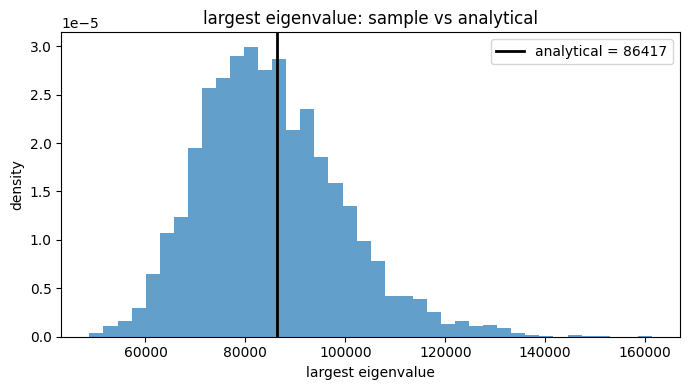

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(lam_max, density=True, bins=40, alpha=0.7)

ax.axvline(an_max, color="k", linewidth=2, label=f"analytical = {an_max:.0f}")

ax.set_xlabel("largest eigenvalue")

ax.set_ylabel("density")

ax.set_title("largest eigenvalue: sample vs analytical")

ax.legend()

plt.tight_layout()

plt.show()

Testing smallest eigenvalue

I have used Symlog scale so negatives, zero, and positives all show. The analytical smallest (black) is a tiny positive number; the dashed red line is zero. Most of the sample distribution sits left to zero which is the smallest eigenvalue collapses negative. 

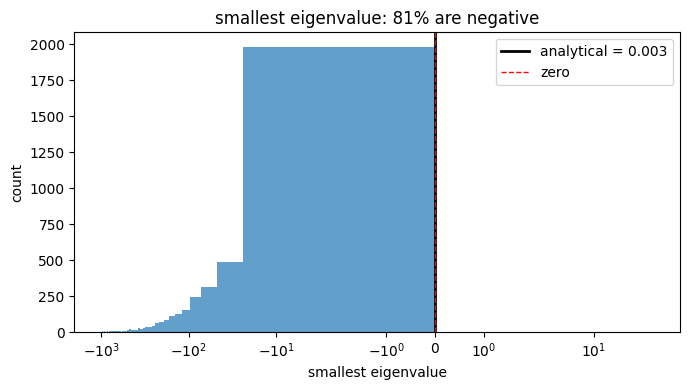

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(lam_min, bins=80, alpha=0.7)

ax.axvline(an_min, color="k", linewidth=2, label=f"analytical = {an_min:.3f}")

ax.axvline(0, color="#f20b0b", linewidth=1, linestyle="--", label="zero")

ax.set_xscale("symlog")

ax.set_xlabel("smallest eigenvalue")

ax.set_ylabel("count")

ax.set_title(f"smallest eigenvalue: {np.mean(lam_min < 0) * 100:.0f}% are negative")

ax.legend()
plt.tight_layout()

plt.show()

Testing how many eigenvalues go negative per matrix

rather than just 'is the smallest negative', this counts how many of the 126 eigenvalues are negative in each matrix. most matrices lose only a few directions; a tail lose many.

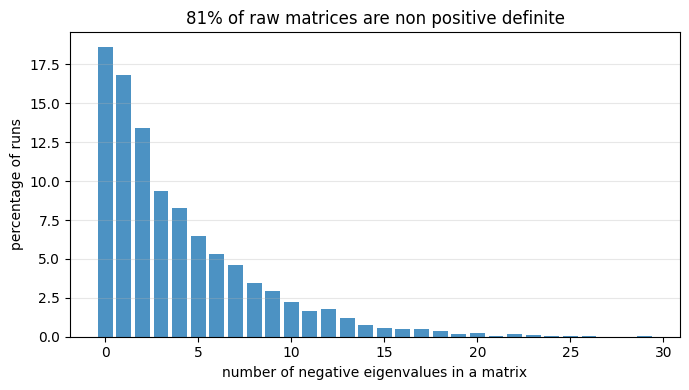

distribution of negative counts:
  0: 763 (18.6%)
  1: 690 (16.8%)
  2: 550 (13.4%)
  3: 384 (9.4%)
  4: 340 (8.3%)
  5: 266 (6.5%)
  6: 218 (5.3%)
  7: 188 (4.6%)
  8: 142 (3.5%)
  9: 121 (3.0%)
  10: 92 (2.2%)
  11: 68 (1.7%)
  12: 74 (1.8%)
  13: 48 (1.2%)
  14: 31 (0.8%)
  15: 24 (0.6%)
  16: 20 (0.5%)
  17: 21 (0.5%)
  18: 16 (0.4%)
  19: 7 (0.2%)
  20: 11 (0.3%)
  21: 3 (0.1%)
  22: 6 (0.1%)
  23: 4 (0.1%)
  24: 3 (0.1%)
  25: 2 (0.0%)
  26: 2 (0.0%)
  29: 2 (0.0%)


In [11]:
n_neg = np.sum(ev < 0, axis=1)

counts = np.bincount(n_neg)

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(range(len(counts)), counts / len(n_neg) * 100, alpha=0.8)

ax.set_xlabel("number of negative eigenvalues in a matrix")

ax.set_ylabel("percentage of runs")

ax.set_title(f"{np.mean(n_neg >= 1) * 100:.0f}% of raw matrices are non positive definite")

ax.grid(alpha=0.3, axis="y")

plt.tight_layout()


plt.show()

print("distribution of negative counts:")

for k in range(len(counts)):
    
    if counts[k] > 0:
        print(f"  {k}: {counts[k]} ({counts[k] / len(n_neg) * 100:.1f}%)")

-----------------------------------------------------------------------------------------------------------------------------

Suspect A test: does reducing window overlap help?

Suspect A says overlapping MSD windows make adjacent rows of the covariance near identical, collapsing the smallest eigenvalue. If true, spacing the timesteps out (less overlap) should reduce the negatives.

The difficulty: subsampling reduces overlap and shrinks the matrix at the same time, so the two effects are hard to separate. The tests below try to provoke them apart.

Test 1 - quick slice 

Taking the existing 126×126 matrices and slice out every Nth row/column (ex. stride 1, 2, 4, 8). 

Fast, but overlap and size shrink together - so this is just a screen to see if there's any effect at all.

In [12]:
n_runs, full_size, _ = cov.shape


strides = [1, 2, 4, 8]



print("strided slicing (overlap reduced + size reduced together):")

for s in strides:
    idx = np.arange(0, full_size, s)
    lam_min = []
    lam_max = []


    for k in range(n_runs):
        sub = cov[k][np.ix_(idx, idx)]
        ev = np.linalg.eigvalsh(sub)


        lam_min.append(ev[0])
        lam_max.append(ev[-1])


    lam_min = np.array(lam_min)
    lam_max = np.array(lam_max)

    
    print(f"  stride {s}: size {len(idx):3d}  "
          
          f"median lambda_min {np.median(lam_min):10.3f}  "
          
          f"fraction negative {np.mean(lam_min < 0):.3f}")

strided slicing (overlap reduced + size reduced together):
  stride 1: size 126  median lambda_min    -26.654  fraction negative 0.814
  stride 2: size  63  median lambda_min     -4.378  fraction negative 0.591
  stride 4: size  32  median lambda_min      0.005  fraction negative 0.427
  stride 8: size  16  median lambda_min      0.005  fraction negative 0.171


Test 2 - same size control

compare a spaced sub matrix vs a consecutive one of the same size, to try to hold matrix size fixed and isolate the overlap effect. (As the output shows, the two still span different time ranges - which is why a faithful rebuild is needed instead.)

In [13]:
target = 16

stride = 4

spaced_idx = np.arange(0, target * stride, stride)

spaced_idx = spaced_idx[spaced_idx < full_size]

consec_start = spaced_idx[0]

consec_idx = np.arange(consec_start, consec_start + len(spaced_idx))



print("spaced span:", spaced_idx[0], "to", spaced_idx[-1], "size", len(spaced_idx))
print("consec span:", consec_idx[0], "to", consec_idx[-1], "size", len(consec_idx))
print()




for label, idx in [("spaced  ", spaced_idx), ("consec  ", consec_idx)]:
    lam_min = np.array([np.linalg.eigvalsh(cov[k][np.ix_(idx, idx)])[0] for k in range(n_runs)])
    print(f"  {label} size {len(idx)}  span {idx[0]}-{idx[-1]}  "
          f"median lambda_min {np.median(lam_min):10.4f}  negative {np.mean(lam_min<0):.3f}")

spaced span: 0 to 60 size 16
consec span: 0 to 15 size 16

  spaced   size 16  span 0-60  median lambda_min     0.0047  negative 0.000
  consec   size 16  span 0-15  median lambda_min     0.0025  negative 0.000


---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Test 3 - faithful rebuild

The proper test: re-run kinisi from scratch with different numbers of time intervals like (126, 63, 32, 16), all spanning the same time range (2 to 128). kinisi recomputes the sample counts correctly for each spacing. 

Comparing these against the slice results at matched size tells us whether reducing overlap genuinely helps.

so its just run with a small number of seeds first to check it works, then i will scale up

In [14]:
base = Path.home() / "Desktop" / "Dissertation" / "kappa-kinisi"

out = base / "data"

out.mkdir(parents=True, exist_ok=True)

In [15]:
def walk(atoms, timesteps, jump_size, seed):

    possible_moves = np.zeros((6, 3))

    j = 0


    for i in range(0, 6, 2):

        possible_moves[i, j] = jump_size

        possible_moves[i + 1, j] = -jump_size

        j += 1

    choices = seed.choice(6, size=(atoms, timesteps))

    steps = possible_moves[choices]
    
    return np.cumsum(steps, axis=1)

In [16]:
def raw_covariance(d):

    da = d.dg['da']

    variances = da.data.variances

    n_samples = da.coords['n_samples'].values

    n = variances.size

    cov = np.zeros((n, n))

    for i in range(n):

        for j in range(i, n):

            ratio = n_samples[i] / n_samples[j]

            cov[i, j] = ratio * variances[i]

            cov[j, i] = cov[i, j]
            
    regime = d.diff.diff_regime
    return cov[regime:, regime:]

In [17]:
def run_one(seed, atoms, length, jump, num_intervals):


    rng = np.random.RandomState(seed)

    steps = walk(atoms, length, jump, rng)

    dims = np.tile([200.0, 200.0, 200.0, 90.0, 90.0, 90.0], (steps.shape[1], 1))

    u = mda.Universe.empty(steps.shape[0], trajectory=True)

    u.add_TopologyAttr('name', [f'Atom{k}' for k in range(steps.shape[0])])

    u.add_TopologyAttr('type', ['A'] * steps.shape[0])

    u.trajectory = MemoryReader(np.transpose(steps, (1, 0, 2)), dimensions=dims, delta=1.0)

    d = DiffusionAnalyzer.from_universe(u, time_step=1.0 * sc.Unit('s'), step_skip=1,
                                        distance_unit=sc.Unit('m'), specie='A',
                                        dt=sc.linspace(dim='time interval', start=2 * sc.Unit('s'),
                                        stop=length * sc.Unit('s'), num=num_intervals),
                                        progress=False)
    
    d.diffusion(2 * sc.Unit('s'), progress=False)
    
    return raw_covariance(d)

In [18]:
atoms = int(2 ** 7)

length = int(2 ** 7)

jump = np.sqrt(6)

size = 128

num_options = [126, 63, 32, 16]

print(f"time range fixed at 2 to {length}; varying number of intervals (= spacing)")

print(f"{size} runs each\n")

time range fixed at 2 to 128; varying number of intervals (= spacing)
128 runs each



In [19]:
results = {}
for num in num_options:

    lam_min = []

    for seed in tqdm(range(size), desc=f"num={num}"):
        c = run_one(seed, atoms, length, jump, num)
        lam_min.append(np.linalg.eigvalsh(c)[0])


    lam_min = np.array(lam_min)

    results[num] = lam_min

    spacing = (length - 2) / num
    
    print(f"  num {num:3d} (spacing {spacing:.2f}, matrix size {len(c)})  "
          f"median lambda_min {np.median(lam_min):10.4f}  negative {np.mean(lam_min<0):.3f}")

num=126:   0%|          | 0/128 [00:00<?, ?it/s]/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
num=126: 100%|██████████| 128/128 [00:47<00:00,  2.68it/s]


  num 126 (spacing 1.00, matrix size 126)  median lambda_min   -25.1256  negative 0.789


num=63: 100%|██████████| 128/128 [00:39<00:00,  3.23it/s]


  num  63 (spacing 2.00, matrix size 63)  median lambda_min    -7.3850  negative 0.633


num=32: 100%|██████████| 128/128 [00:37<00:00,  3.44it/s]


  num  32 (spacing 3.94, matrix size 32)  median lambda_min     0.0046  negative 0.469


num=16: 100%|██████████| 128/128 [00:29<00:00,  4.33it/s]

  num  16 (spacing 7.88, matrix size 16)  median lambda_min     0.0052  negative 0.273


Looking directly at the collapsing direction

looking at what the bad eigenvalue's eigenvector looks like. 


Suspect A predicts an oscillation spread across all timesteps. If instead it's concentrated at the long time end, the collapse is driven by noisy long time variance, not by overlap.

Eigenvector of the smallest eigenvalue (seed 0)

If this is flat across most indices and spikes only at the long time end, the collapse is localised at long times - pointing at noise (which is our Suspects B-variance/D-Floating point error) rather than uniform overlap (A).

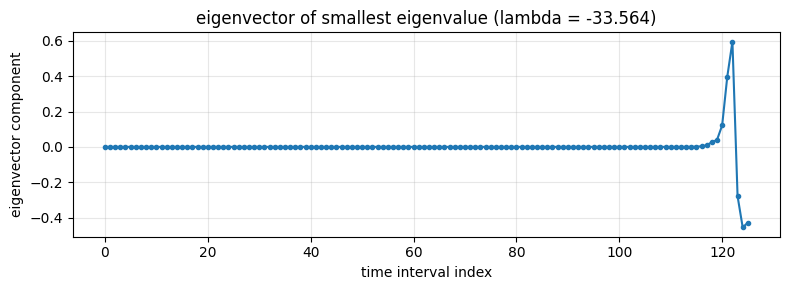

In [20]:
vals, vecs = np.linalg.eigh(cov[0])

smallest_vec = vecs[:, 0]



fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(smallest_vec, marker="o", markersize=3)

ax.set_xlabel("time interval index")
ax.set_ylabel("eigenvector component")
ax.set_title(f"eigenvector of smallest eigenvalue (lambda = {vals[0]:.3f})")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

checking adjacent row correlation

checks Suspect A's premise directly: are adjacent rows of the covariance near identical? 

a value near 1.0 confirms the rows are near proportional everywhere (so A's premise holds, even if it isn't what triggers the collapse).

In [21]:
c = cov[0]

n = c.shape[0]

adjacent_corr = []

for i in range(n - 1):
    r1, r2 = c[i], c[i+1]
    adjacent_corr.append(np.corrcoef(r1, r2)[0, 1])
adjacent_corr = np.array(adjacent_corr)



print("mean adjacent row correlation:", adjacent_corr.mean())

print("min:", adjacent_corr.min(), "max:", adjacent_corr.max())

mean adjacent row correlation: 0.9999813590238581
min: 0.9999491047257022 max: 0.9999999691183739


Eigenvector across several seeds

The seed 0 eigenvector is only one matrix. This checks whether the long time localisation holds across seeds (0, 1, 2, 5, 11, 20). 

If all spike at the long time end, the finding is robust.

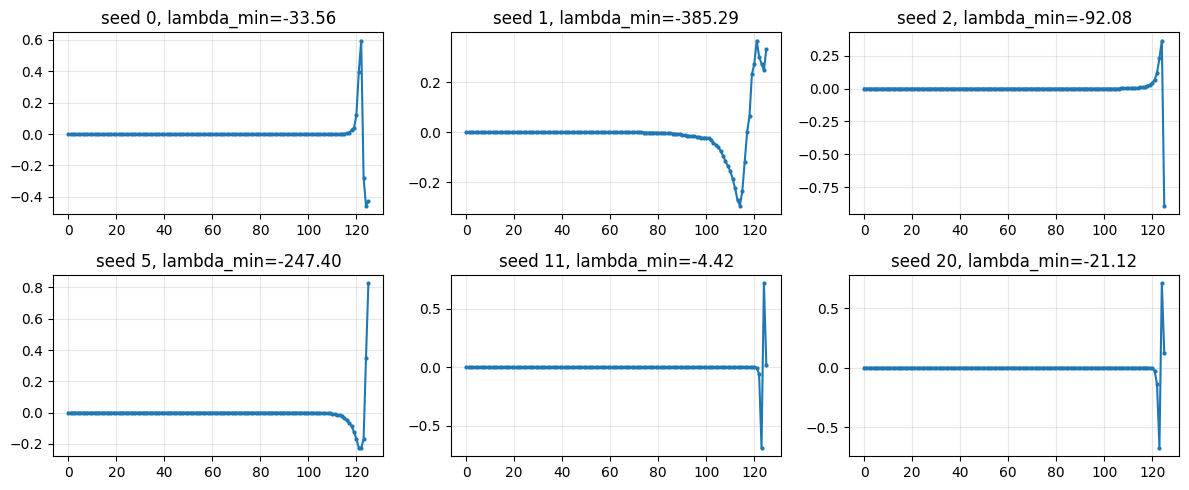

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(12, 5))

for ax, k in zip(axes.flat, [0, 1, 2, 5, 11, 20]):
    vals, vecs = np.linalg.eigh(cov[k])
    ax.plot(vecs[:, 0], marker="o", markersize=2)
    ax.set_title(f"seed {k}, lambda_min={vals[0]:.2f}")
    ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()

Hey Andrew, bit of an update on the Suspect A stuff (the timestep correlation idea) - still working through it but wanted to share where I've landed so far.

So the basic premise actually holds up: adjacent rows of the covariance are almost perfectly correlated (0.99998), so the overlapping windows really are making adjacent times nearly  identical, like we thought.

But here's the twist - that doesn't seem to be what's actually causing the collapse. When I rebuild with less overlap, the smallest eigenvalue doesn't get better, it actually gets a worse. And when I look at the eigenvector of the collapsing eigenvalue, it's not spread across all the timesteps like I'd expect if overlap were the culprit - it's all bunched up at the long time end.

So my hunch right now is that the real trouble is the long time tail, where there's hardly any data and the variance gets noisy. That points more at the noise suspects - B (too few independent samples at long times) and D (floating point cancellation in the variance, the one Cameron raised). The nearly identical rows from A make the matrix fragile, and then the long time noise is what actually pushes it over the edge. Still poking at this though.

It also makes the size effect (C - bigger matrix, more near dependent rows) look less like its own thing - shrinking the matrix mostly just chops off that noisy long time region.

So basically the suspects seem to be tangled together rather than one clean culprit: A sets up the fragile structure, B/D provides the noise that triggers the collapse, and what looked like C is mostly just cutting off the noisy tail. One big caveat: the eigenvector thing is just one seed so far, so I want to check it holds up across more before I trust it - doing that next, plus an atom count sweep to figure out if it's B or D. Can walk you through the plots Monday.

# Structural Analysis 

structural tests on the analytical matrix

The spacing tests above couldn't cleanly separate the suspects (overlap, size and
time range all change together). The analytical (S 32) matrix is noise free by
construction, so anything near singular about it is purely structural (A or C suspects).
Comparing the analytical matrix against the sample matrices isolates the noise (B/D suspects).

Test 1 - analytical vs sample eigenvector

Build the analytical matrix and take the eigenvector of its smallest eigenvalue,
alongside the sample one. If the noise free (analytical) fragile direction sits at a
different place than the noisy (sample) one, the difference is caused by noise.

In [23]:
length = 128

dimensionality = 3

D = 6 / (dimensionality * 2)

timestep = msd[0, :, 0]

no = msd[0, :, 3]

an_cov = np.zeros((no.shape[0], no.shape[0]))

for i in range(an_cov.shape[0]):
    for j in range(i, an_cov.shape[1]):
        an_cov[i, j] = 8 * dimensionality**2 * D**2 * timestep[i]**2 / (dimensionality * no[j])
        an_cov[j, i] = an_cov[i, j]

an_vals, an_vecs = np.linalg.eigh(an_cov)

samp_vals, samp_vecs = np.linalg.eigh(cov[0])

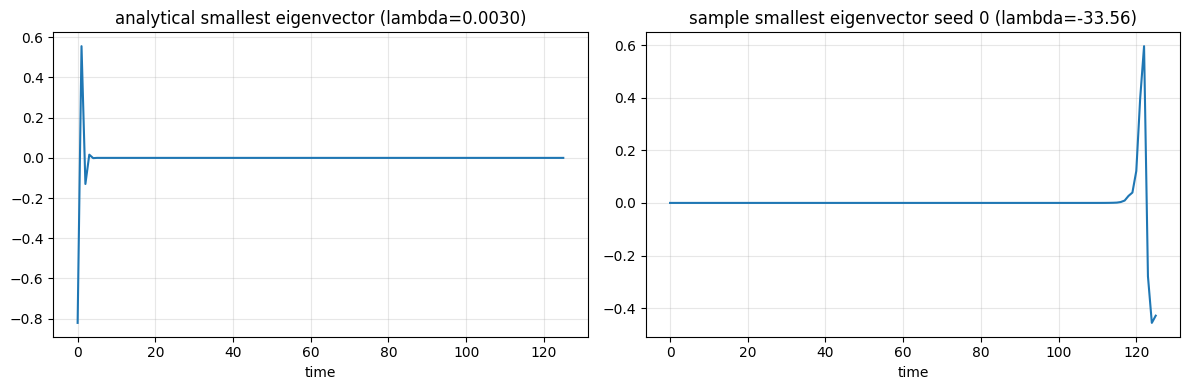

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(an_vecs[:, 0])

ax[0].set_title(f"analytical smallest eigenvector (lambda={an_vals[0]:.4f})")

ax[0].set_xlabel("time")

ax[0].grid(alpha=0.3)

ax[1].plot(samp_vecs[:, 0])

ax[1].set_title(f"sample smallest eigenvector seed 0 (lambda={samp_vals[0]:.2f})")

ax[1].set_xlabel("time")
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

analytical eigenvector spikes at the  short time end; sample spikes at the
long time end. They are at opposite ends - so the noise is what moves the collapse to
long times. The structural fragility is at short times; the long time collapse is noise driven (B/D).

Test 2 - overlapping vs non overlapping 

The near identical rows come from the N'_i/N'_j ratio, which encodes the window overlap.

This rebuilds the analytical matrix two ways - with kinisi's overlapping sample counts,
and with non overlapping ones - keeping the variance and size fixed. Only the overlap
structure changes, so any difference in lambda_min is purely the overlap effect (which is suspect A).

In [25]:
n = no.shape[0]

sigma2 = an_cov.diagonal().copy()

def build(nprime):
    m = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            m[i, j] = sigma2[i] * nprime[i] / nprime[j]
            m[j, i] = m[i, j]
    return m


no_overlap = no.copy()

T = length

no_nonoverlap = np.array([T / timestep[i] for i in range(n)])


for label, npr in [("overlapping (kinisi)", no_overlap), ("non overlapping", no_nonoverlap)]:
    m = build(npr)

    ev = np.linalg.eigvalsh(m)
    
    print(f"  {label:22s} lambda_min {ev[0]:.5f}  lambda_max {ev[-1]:.1f}  cond {ev[-1]/abs(ev[0]):.2e}")

  overlapping (kinisi)   lambda_min 0.00300  lambda_max 86417.0  cond 2.88e+07
  non overlapping        lambda_min 0.00300  lambda_max 86417.0  cond 2.88e+07


identical lambda_min and condition number. Changing the overlap structure
makes no difference - so overlap (A) is not the structural driver of the near singularity.

the non overlapping N' is an approximation - worth confirming what n_samples
physically counts before trusting the exact magnitude.

Test 3 - surgically replace the long time tail

Take a sample matrix that went negative, and replace only its noisy long time region with
the noise free analytical values. If the collapse disappears, the long time noise was
causally responsible.

In [26]:
bad_seed = 0

samp = cov[bad_seed].copy()

n = samp.shape[0]

print("original sample lambda_min:", np.linalg.eigvalsh(samp)[0])

for cut in [0.9, 0.8, 0.7]:
    start = int(n * cut)
    
    hybrid = samp.copy()

    hybrid[start:, :] = an_cov[start:, :]

    hybrid[:, start:] = an_cov[:, start:]

    ev = np.linalg.eigvalsh(hybrid)


    print(f"  replaced long time tail from index {start} ({int((1-cut)*100)}% of times): "
          f"lambda_min {ev[0]:.4f}  negative? {ev[0] < 0}")

original sample lambda_min: -33.56415225811641
  replaced long time tail from index 113 (9% of times): lambda_min 0.0022  negative? False
  replaced long time tail from index 100 (19% of times): lambda_min 0.0019  negative? False
  replaced long time tail from index 88 (30% of times): lambda_min -0.6492  negative? True


replacing the last 10 to 20% of time intervals lifts lambda_min back positive -
so the long time noise is causally what tips the matrix negative.

test - 4 analytical lambda_min vs size (mormal structural C, noise free)

Check whether the noise free  matrix is sensitive to size. If it stays positive 
at every size, then 'size matters' in the sample data is really about removing the noisy
long time tail, not a structural size effect.

In [27]:
print("analytical matrix (noise free) lambda_min at different sizes:")

for num in [126, 63, 32, 16]:

    idx = np.linspace(0, an_cov.shape[0] - 1, num).astype(int)

    sub = an_cov[np.ix_(idx, idx)]

    ev = np.linalg.eigvalsh(sub)
    
    print(f"  size {num:3d}: lambda_min {ev[0]:.5f}  negative? {ev[0] < 0}")

analytical matrix (noise free) lambda_min at different sizes:
  size 126: lambda_min 0.00300  negative? False
  size  63: lambda_min 0.00544  negative? False
  size  32: lambda_min 0.00771  negative? False
  size  16: lambda_min 0.00936  negative? False


the analytical matrix is positive definite at every size (lambda_min stays
positive,  0.003 to 0.009). So size (C) is not an independent structural driver - shrinking
helps the sample matrices only by cutting off the noisy tail.

Conclusion: the collapse is driven by noise in the long time variance estimates
(suspects B/D), not by overlap (A) or size (C). The noise free matrix is near singular
but always positive definite; the noisy long time tail is what tips it negative.

Still to confirm: the eigenvector results use seed 0 (multi seed check above should
confirm the pattern generalises). 


Next: N_atoms sweep to separate B (sample count
noise, fixable with more atoms) from D (floating-point, not fixable).

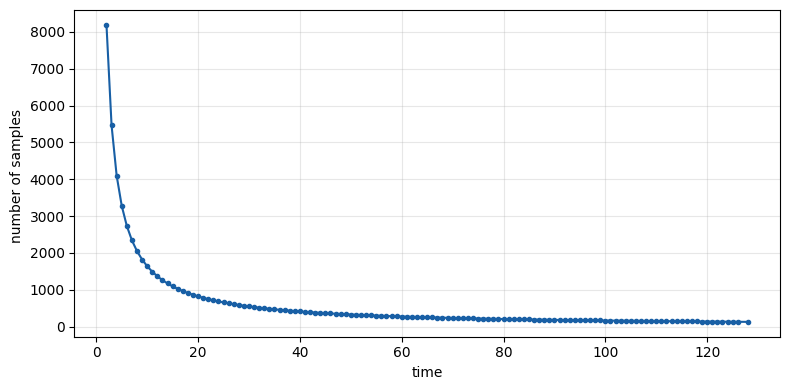

at shortest lag: 8192.0
at longest lag: 128.0
ratio: 64.0


In [51]:
timestep = msd[0, :, 0]

n_samples = msd[0, :, 3]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(timestep, n_samples, marker="o", markersize=3, color="#185fa5")
ax.set_xlabel("time")
ax.set_ylabel("number of samples ")
ax.grid(alpha=0.3)
plt.tight_layout()


plt.show()


print("at shortest lag:", n_samples[0])
print("at longest lag:", n_samples[-1])
print("ratio:", n_samples[0] / n_samples[-1])

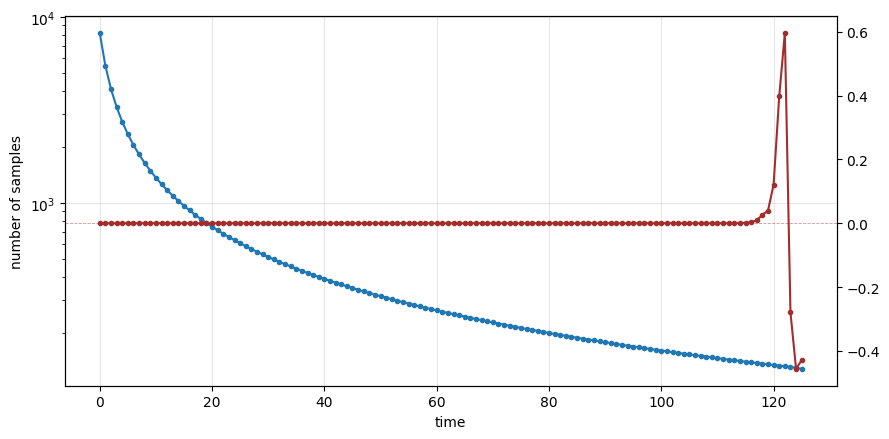

In [52]:
n_samples = msd[0, :, 3]
vals, vecs = np.linalg.eigh(cov[0])
smallest_vec = vecs[:, 0]


idx = np.arange(len(n_samples))


fig, ax1 = plt.subplots(figsize=(9, 4.5))


ax1.plot(idx, n_samples, marker="o", markersize=3, label="N' (samples)")
ax1.set_xlabel("time")
ax1.set_ylabel("number of samples")
ax1.tick_params(axis="y")
ax1.set_yscale("log")
ax1.grid(alpha=0.3)


ax2 = ax1.twinx()
ax2.plot(idx, smallest_vec, color="#a32d2d", marker="o", markersize=3, label="smallest eigenvector")
ax2.tick_params(axis="y")
ax2.axhline(0, color="#a32d2d", linewidth=0.6, linestyle="--", alpha=0.5)



fig.tight_layout()
plt.show()